In [2]:
# IMPORTATION DES LIBRAIRIES

# Gestion des fichiers et dossiers
import os
import zipfile
import random

# Accès à Google Drive (dataset stocké sur Drive)
from google.colab import drive

# Calcul scientifique (tableaux, opérations mathématiques)
import numpy as np

# Visualisation des images et des résultats
import matplotlib.pyplot as plt
import seaborn as sns # Pour afficher la matrice de confusion sous forme de heatmap

# Deep Learning avec TensorFlow / Keras
import tensorflow as tf

# Génération et prétraitement des images (normalisation, augmentation)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

# Modèle CNN pré-entraîné (Transfer Learning)
from tensorflow.keras.applications import MobileNetV2

# Couches du réseau de neurones
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Modèle Keras
from tensorflow.keras.models import Model

# Optimiseur qui ajuste les poids du réseau
from tensorflow.keras.optimizers import Adam

# Évaluation du modèle pour mesurer les performances du modèle
from sklearn.metrics import confusion_matrix, classification_report

# Webcam (JavaScript + OpenCV)
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2 # traitement d’image (afficher texte, rectangle sur image webcam)

print("Librairies importées avec succès")


Librairies importées avec succès


In [13]:
# MONTAGE DU GOOGLE DRIVE

print(" Connexion à Google Drive...")
drive.mount('/content/drive')

nom_dossier_drive = "Projet_CNN"
nom_zip = "mask_dataset.zip"

# Chemin COMPLET du fichier zip dans Google Drive
chemin_zip = f"/content/drive/MyDrive/{nom_dossier_drive}/{nom_zip}"

# Dossier local où le dataset sera extrait
dataset_path = "/content/dataset_mask/data/data/data/data"


print("Chemin du zip :", chemin_zip)
print("Dossier d'extraction :", dataset_path)

# Vérifier si le fichier zip existe dans Drive
if os.path.exists(chemin_zip):
    print("Dataset trouvé dans Google Drive")

    # Vérifier si le dataset a déjà été extrait
    if not os.path.exists(dataset_path):
        print("Extraction du dataset en cours...")

        # Extraction du fichier zip
        with zipfile.ZipFile(chemin_zip, 'r') as zip_ref:
            zip_ref.extractall(dataset_path)

        print("Extraction terminée avec succès !!")
    else:
        print("Dataset déjà extrait — aucune action nécessaire")

else:
    print("ERREUR : fichier zip introuvable dans Google Drive")
    print("📂 Contenu du dataset :")
!ls {dataset_path}

 Connexion à Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Chemin du zip : /content/drive/MyDrive/Projet_CNN/mask_dataset.zip
Dossier d'extraction : /content/dataset_mask/data/data/data/data
Dataset trouvé dans Google Drive
Dataset déjà extrait — aucune action nécessaire
with_mask  without_mask


In [14]:
# DÉFINITION DES DOSSIERS


# Dossier d'entraînement
train_dir = os.path.join(dataset_path, "train")

# Dossier de test
test_dir  = os.path.join(dataset_path, "test")

print("Train :", train_dir)
print("Test  :", test_dir)


Train : /content/dataset_mask/data/data/data/data/train
Test  : /content/dataset_mask/data/data/data/data/test


In [15]:
# PARAMÈTRES GLOBAUX DU CNN

# Taille des images d'entrée du réseau
IMG_SIZE = 96

# Nombre d'images traitées en parallèle
BATCH_SIZE = 32

# Nombre d'époques d'entraînement
EPOCHS = 15

print("Paramètres configurés")

Paramètres configurés


In [17]:
# DATA AUGMENTATION
# Permet :
# - d'augmenter artificiellement le dataset
# - de réduire l'overfitting
# - d'améliorer la généralisation du CNN

train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalisation des pixels (0 → 1)
    rotation_range=20,       # Rotation aléatoire
    zoom_range=0.2,          # Zoom
    horizontal_flip=True,    # Miroir horizontal
    validation_split=0.2     # 80% entraînement / 20% validation
)


In [18]:
# GÉNÉRATEURS D'IMAGES

# GÉNÉRATEUR D’ENTRAÎNEMENT (80 %)
train_gen = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# 20% → VALIDATION (TEST)
val_gen = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_labels = list(train_gen.class_indices.keys())
num_classes = len(class_labels)

print("Classes détectées :", class_labels)
print("Nombre de classes :", num_classes)

Found 6043 images belonging to 2 classes.
Found 1510 images belonging to 2 classes.
Classes détectées : ['with_mask', 'without_mask']
Nombre de classes : 2


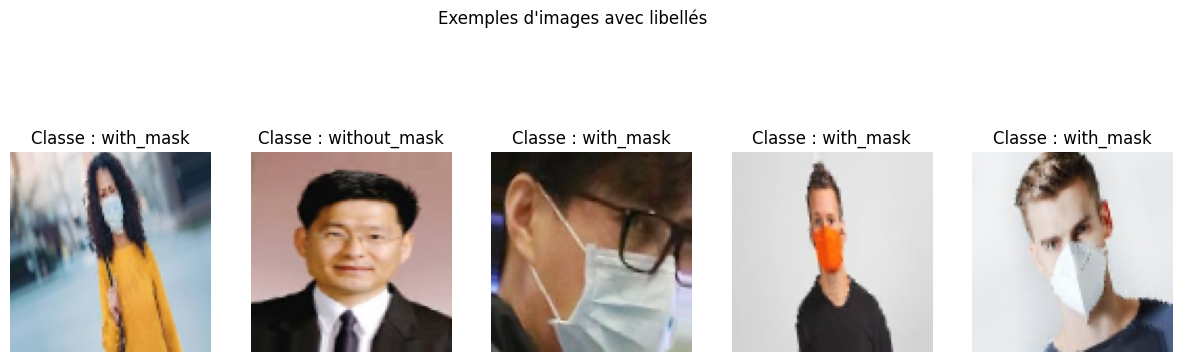

In [19]:
# VISUALISATION DU DATASET

images, labels = next(train_gen)

plt.figure(figsize=(15,5))

for i in range(5):
    true_label = class_labels[np.argmax(labels[i])]

    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.title(f"Classe : {true_label}")
    plt.axis("off")

plt.suptitle("Exemples d'images avec libellés")
plt.show()


In [20]:
# MODÈLE CNN : MOBILENETV2

# Il contient :
# - des couches de convolution
# - des filtres
# - du pooling
# - des activations ReLU
# tout est déjà optimisé

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,       # On enlève le classifieur final
    weights='imagenet'       # Poids pré-entraînés
)

# On gèle les 80 premières couches (ne seront pas ré-entraînées)
# Elles détectent déjà les contours, textures, formes
for layer in base_model.layers[:80]:
    layer.trainable = False

# AJOUT DU CLASSIFIEUR

x = base_model.output

# Remplace Flatten → moins de paramètres
x = GlobalAveragePooling2D()(x)

# Couche fully connected de 128 neurones, (apprentissage de la décision)
x = Dense(128, activation='relu')(x)

# Dropout : évite l'overfitting
x = Dropout(0.5)(x)

# Couche de sortie (MASK / NO MASK)
output = Dense(num_classes, activation='softmax')(x)

# Modèle final
model = Model(inputs=base_model.input, outputs=output)


In [21]:
# COMPILATION DU MODÈLE

model.compile(
    optimizer=Adam(1e-4),  # algorithme qui met à jour les poids du réseau pour minimiser les pertes
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), # mesure l'erreur pour éviter que le modèle soit trop sûr de lui
    metrics=['accuracy'] # # demander au modèle de suivre la précision
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 2,203,010 (8.40 MB)

 Non-trainable params: 219,200 (856.25 KB)

In [22]:
# ENTRAÎNEMENT DU CNN
# Le modèle apprend :
# - sur 80% des données
# - validé sur 20%
# - enregistre les résultats dans history

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
126/189 ━━━━━━━━━━━━━━━━━━━━ 17s 280ms/step - accuracy: 0.7899 - loss: 0.5839

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


189/189 ━━━━━━━━━━━━━━━━━━━━ 98s 324ms/step - accuracy: 0.8247 - loss: 0.5261 - val_accuracy: 0.8437 - val_loss: 0.5226
Epoch 2/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 28s 150ms/step - accuracy: 0.9631 - loss: 0.2993 - val_accuracy: 0.8563 - val_loss: 0.4854
Epoch 3/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 28s 148ms/step - accuracy: 0.9781 - loss: 0.2611 - val_accuracy: 0.8841 - val_loss: 0.4160
Epoch 4/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 28s 148ms/step - accuracy: 0.9877 - loss: 0.2485 - val_accuracy: 0.9026 - val_loss: 0.3902
Epoch 5/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 28s 147ms/step - accuracy: 0.9903 - loss: 0.2358 - val_accuracy: 0.9338 - val_loss: 0.3207
Epoch 6/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 28s 148ms/step - accuracy: 0.9942 - loss: 0.2281 - val_accuracy: 0.9371 - val_loss: 0.3133
Epoch 7/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 28s 147ms/step - accuracy: 0.9900 - loss: 0.2289 - val_accuracy: 0.9735 - val_loss: 0.2638
Epoch 8/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 29s 151ms/step - accuracy: 0.9945 - loss: 0.2222 - val

In [23]:
# ÉVALUATION SUR LE TEST

loss, acc = model.evaluate(val_gen)
print(f"Accuracy finale : {acc*100:.2f}%")
print(f"Loss finale : {loss:.4f}")


48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.9902 - loss: 0.2188
Accuracy finale : 99.07%
Loss finale : 0.2163


48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 174ms/step


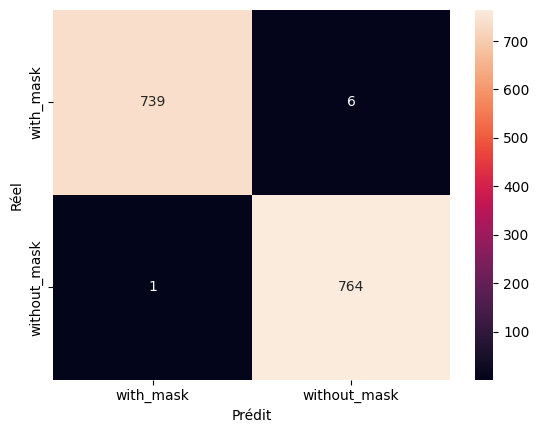

              precision    recall  f1-score   support

   with_mask       1.00      0.99      1.00       745
without_mask       0.99      1.00      1.00       765

    accuracy                           1.00      1510
   macro avg       1.00      1.00      1.00      1510
weighted avg       1.00      1.00      1.00      1510



In [24]:
# MATRICE DE CONFUSION

preds = model.predict(val_gen)
y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_labels))


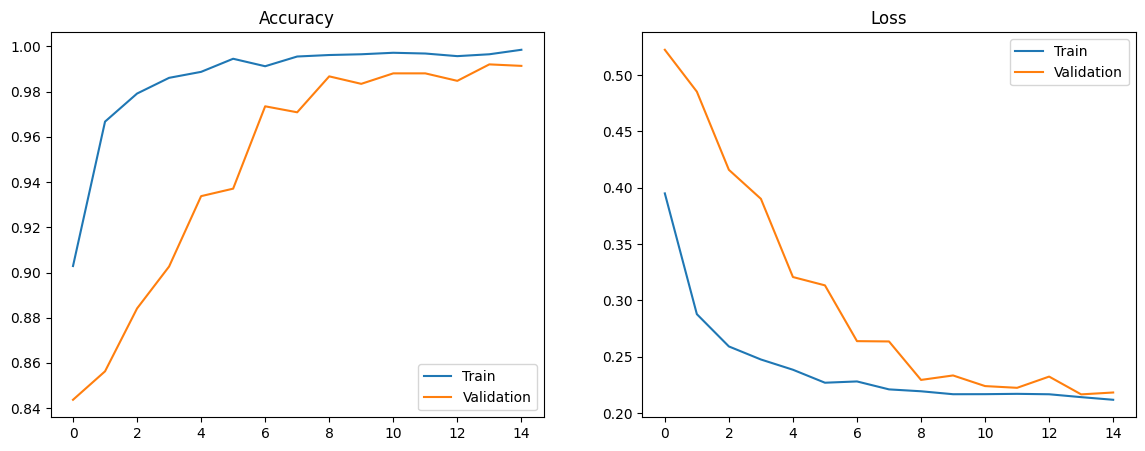

In [25]:
# COURBES ACCURACY & LOSS

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train")
plt.plot(history.history['val_accuracy'], label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train")
plt.plot(history.history['val_loss'], label="Validation")
plt.title("Loss")
plt.legend()

plt.show()


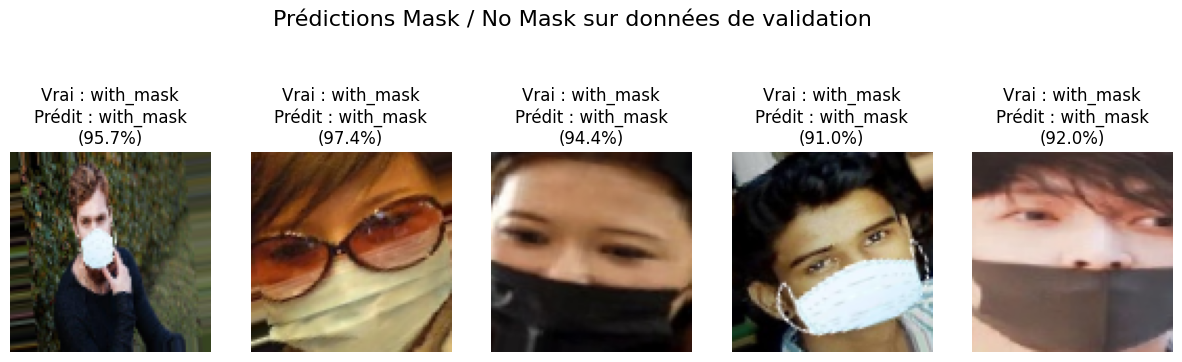

In [26]:

# TEST SUR 5 IMAGES (VALIDATION = TEST)

# On récupère un batch depuis le générateur de validation
images, labels = next(val_gen)

plt.figure(figsize=(15,5))

for i in range(5):
    # Image
    img = images[i]

    # Classe vraie
    true_label = class_labels[np.argmax(labels[i])]

    # Prédiction du modèle
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
    predicted_label = class_labels[np.argmax(pred)]
    confidence = np.max(pred)

    # Affichage
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(
        f"Vrai : {true_label}\n"
        f"Prédit : {predicted_label}\n"
        f"({confidence*100:.1f}%)",
        fontsize=12
    )
    plt.axis("off")

plt.suptitle("Prédictions Mask / No Mask sur données de validation", fontsize=16)
plt.show()


 Prenez une photo...


<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


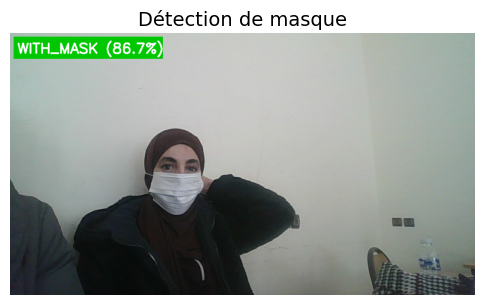

In [33]:
# ETAPE 15 : WEBCAM COLAB + TEXTE SUR IMAGE

def take_photo(filename='photo.jpg', quality=0.9):
    js = Javascript('''
      async function takePhoto(quality) {
        const div = document.createElement('div');
        const btn = document.createElement('button');
        btn.textContent = '📸 PRENDRE UNE PHOTO';
        btn.style.fontSize = '20px';
        btn.style.padding = '15px';
        btn.style.background = '#4CAF50';
        btn.style.color = 'white';
        btn.style.border = 'none';
        btn.style.borderRadius = '8px';

        const video = document.createElement('video');
        div.appendChild(btn);
        div.appendChild(video);
        document.body.appendChild(div);

        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        video.srcObject = stream;
        await video.play();

        await new Promise(resolve => btn.onclick = resolve);

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);

        stream.getTracks().forEach(track => track.stop());
        div.remove();

        return canvas.toDataURL('image/jpeg', quality);
      }
    ''')
    display(js)
    data = eval_js(f'takePhoto({quality})')
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

print(" Prenez une photo...")
filename = take_photo()

# Prédiction
img = image.load_img(filename, target_size=(IMG_SIZE, IMG_SIZE))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0) / 255.0

pred = model.predict(x)
idx = np.argmax(pred)
label = class_labels[idx]
confidence = pred[0][idx]

# Affichage avec OpenCV
img_cv = cv2.imread(filename)
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

text = f"{label.upper()} ({confidence*100:.1f}%)"
color = (0,200,0) if label == "with_mask" else (255,0,0)

cv2.rectangle(img_cv, (10,10), (420,70), color, -1)
cv2.putText(img_cv, text, (20,55),
            cv2.FONT_HERSHEY_SIMPLEX, 1.3,
            (255,255,255), 3)

plt.figure(figsize=(6,6))
plt.imshow(img_cv)
plt.axis("off")
plt.title("Détection de masque", fontsize=14)
plt.show()
